# Operator Dynamics in Random Bricklayer Circuits with Pauli Propagation and MPO

The goal of this notebook is to study the time evolution of a local quantum observable using the Pauli propagation framework implemented in `PauliPropagation.jl` and compare it to the MPO method.



In [165]:
# using Pkg; Pkg.add("LaTeXStrings")
using LaTeXStrings
using Plots
using LinearAlgebra

# --- Pauli Propagation ---
# Pkg.add("PauliPropagation")
using PauliPropagation

#include("../src/pauli_propagation_functions.jl")
include("pauli_propagation_functions.jl")
import .pauli_propagation_functions as pp

# --- MPO ---
# Pkg.add("ITensors"); Pkg.add("ITensorMPS")
using ITensors, ITensorMPS

#include("../src/matrix_product_operator_functions.jl")
include("matrix_product_operator_functions.jl")
import .mpo_functions as mpo

---

# 1. Random Gate Circuit

We will use a random circuits of the form:

$$
U = \prod_j e^{i \theta_j P_j}
$$

where:

- $\theta_j$ are random angles
- $P_j$ are random two-qubit Pauli strings


---

## 1.1 Decomposition of a 4x4 Unitary Matrix into Pauli Rotations

Let $H$ be an Hermitian matrix $\implies H = H^\dagger$.

Let $k \in \mathbb{R}$ and $U = e^{ikH}$.

$\implies U^\dagger = (e^{ikH})^\dagger = e^{-ikH^\dagger} = e^{-ikH}$
$\implies U U^\dagger = e^{ikH} e^{-ikH} = \mathbb{I} \implies U$ is unitary.


Let $\{P_j\}_{j \in I}$ be the set of Pauli strings for 2 qubits ($|I|=16$).
$\{P_j\}$ forms a basis for the space of $4 \times 4$ Hermitian matrices.

$\implies \forall H, \exists c_j \in \mathbb{R} \text{ such that } H = \sum_{j \in I} c_j P_j$.


Since $P_j$ generally do not commute ($[P_a, P_b] \neq 0$), $e^{i \sum c_j P_j} \neq \prod e^{i c_j P_j}$.

However, as $\{P_j\}$ are generators of the $\mathfrak{u}(4)$ Lie Algebra, by Lie Group theory (Cartan decomposition):

$\forall U \in U(4), \exists \theta_k \in \mathbb{R}, P_k \in \{P_j\}$ such that:

$$U = \prod_{k} e^{i \theta_k P_k}$$

Any $4 \times 4$ unitary matrix $U$ can be decomposed into a finite product of Pauli rotations.


---

Let $P$ a Pauli string and $\theta$ a real number.

$$e^{i\theta P} = \sum_{k=0}^{\infty} \frac{(i\theta P)^{2k}}{(2k)!} + \sum_{k=0}^{\infty} \frac{(i\theta P)^{2k+1}}{(2k+1)!}$$

- $(i\theta P)^{2k} = i^{2k} \theta^{2k} P^{2k} = (-1)^k \theta^{2k} (P^2)^k$. By definition  $P^2 = \mathbb I$, so $P^{2k} = \mathbb I$.
- $(i\theta P)^{2k+1} = i^{2k+1} \theta^{2k+1} P^{2k+1} = i(-1)^k \theta^{2k+1} P$.

$$\implies e^{i\theta P} = \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k} \mathbb I}{(2k)!} + \sum_{k=0}^{\infty} \frac{i (-1)^k \theta^{2k+1} P}{(2k+1)!}$$

$$\implies e^{i\theta P} = \mathbb I \left( \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k}}{(2k)!} \right) + i P \left( \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k+1}}{(2k+1)!} \right)$$

And we know :

- $\cos(\theta) = \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k}}{(2k)!}$
- $\sin(\theta) = \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k+1}}{(2k+1)!}$

$$\implies e^{i\theta P} = \cos(\theta) \mathbb I + i \sin(\theta) P \qquad \forall P \in \text{Pauli string, } \forall \theta \in \mathbb R$$

---

The final decomposition is:
$$U = \prod_{k} (\cos(\theta_k) \mathbb{I} + i \sin(\theta_k) P_k)$$

In my function `random_unitary_matrix()`, we use the relation :

$$U = e^{i \sum \theta_j P_j}$$
I'll change that later


And we verify if $U$ is unitary with `@assert U * U' ≈ U' * U ≈ I(4)`.


In [ ]:
using PauliPropagation: Xmat, Ymat, Zmat
# I(n) in LinearAlgebra

function random_unitary_matrix()
  pm = [I(2), Xmat, Ymat, Zmat]

  P = I(4)*0 # zero 4x4 matrix
  for Pi in pm
    for Pj in pm
      theta = rand() * 2π # ∈[0, 2π]
      P += kron(Pi, Pj) * theta # P = ∑ θ_j P_j
    end
  end
  U = exp(im * P) # e^{i ∑ θ_j P_j}
  @assert U * U' ≈ U' * U ≈ I(4) # verify U is a 4x4 unitary matrix
  return U
end

random_unitary_matrix (generic function with 1 method)

---

## 1.2 Mezzadri algo for Haar distribution

1.  **Generation of $Z$**: We create an $n \times n$ matrix where each element is a complex number $a + ib$, with $a, b \sim \mathcal{N}(0, 1)$.
2.  **QR decomposition**: We compute $Q$ and $R$ such that $Z = QR$.
3.  **Phase correction**: We define a diagonal matrix $\Lambda$ such that:
$$\Lambda_{ii} = \frac{R_{ii}}{|R_{ii}|}$$
  The diagonal elements of $R' = \Lambda^{-1}R$ are always real and strictly positive, therefore the matrix $Q' = Q\Lambda$ is **distributed with Haar measure**.

We then compute the final unitary matrix: $U = Q \times \Lambda$.



In [4]:
function haar_unitary(n::Int64)
    # 1. Generation of Z
    Z = randn(ComplexF64, n, n)

    # 2. QR Decomposition
    F = qr(Z)
    Q = Matrix(F.Q)
    R = F.R

    # 3. Phase correction
    d = diag(R)
    ph = d ./ abs.(d)

    U = Q * Diagonal(ph)
    @assert U * U' ≈ U' * U ≈ I(n) # verify U is a nxn unitary matrix
    return U
end

haar_unitary (generic function with 1 method)

---

## 1.3 Matrices to gates

Now we want to use these random unitary matrices as gates to build a quantum circuit of the type :

<img src="https://github.com/TheoHUETQC/Quantum-ManyBody-Sim-Methods/blob/main/figures/brickwork_pattern_circuit.png?raw=1" width="600" alt="Block circuit">

All U are different random 4x4 matrices.

The package allows us to do this using the function `TransferMapGate()`.

In [13]:
function random_block_gate(pair::Tuple{Int64, Int64})
  # need to be 4x4 and unitary
  #U = random_unitary_matrix()
  U = haar_unitary(4)

  # Pauli Propagation
  U_pp = TransferMapGate(U, pair)

  # MPO
  i, j = pair
  s1, s2 = sites[i], sites[j]
  U_mpo = itensor(U, s2', s1', s2, s1)

  return U_pp, U_mpo
end

random_block_gate (generic function with 1 method)

---

## 1.4 Random Circuit

In [14]:
function random_brick_circuit(nqubits::Integer, nlayers::Integer; topology=nothing)
    circuit_pp::Vector{Gate} = []
    circuit_mpo::Vector{Vector{ITensor}} = []

    if isnothing(topology)
        topology = bricklayertopology(nqubits; periodic=false)
    end

    for _ in 1:nlayers
      layer_mpo::Vector{ITensor} = []
      for pair in topology
          U_pp, U_mpo = random_block_gate(pair)
          push!(circuit_pp, U_pp)
          push!(layer_mpo, U_mpo)
      end
      push!(circuit_mpo, layer_mpo)
    end
    return circuit_pp, circuit_mpo
end

random_brick_circuit (generic function with 1 method)

---

# 2. Pauli Propagation method

Let's apply this circuit on a nq qubits chain :

In [ ]:
nq = 8
nlayers = 100

# the truncations
max_weight = 10
min_abs_coeff = 1e-8

topology = bricklayertopology(nq; periodic=true)

# define the circuit as a vector of random block gates
circuit, _ = random_brick_circuit(nq, nlayers; topology)

# Z_i
i=4; Z_i = PauliString(nq, :Z, i) # I...IZI...I

observable = Z_i
println("Observable : ", observable)

Observable : PauliString(nqubits: 8, 1.0 * IIIZIIII)


## 2.1 Layer by layer function vs propagate()

Propagate the observable in the random circuit with the layer by layer function

In [ ]:
#--- layer by layer method
t1 = time()
pauli_sum, result = pp.propagate_layerbylayer(circuit, observable, nlayers; max_weight, min_abs_coeff)
elapsed_time1 = time() - t1

#--- propagate() method
t2 = time()
pauli_sum2 =  propagate(circuit, observable; max_weight, min_abs_coeff)
elapsed_time2 = time() - t2
println("Time taken by propagate: ", elapsed_time2, " seconds")

layer : 0/100 complete
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
Time taken by propagate_layerbylayer: 54.80999994277954 seconds
Time taken by propagate: 52.21300005912781 seconds


Since the circuit is random, it's more complicated than the previous one, the order of the layers and gates changes everything. Let's check whether the layer-by-layer propagation `propagate_bylayers()` actually allows our observable to propagate through the correct circuit.

In [ ]:
println("The two pauli sum are close : ", (pauli_sum ≈ pauli_sum2))

dt = elapsed_time1 - elapsed_time2
if dt < 0
  println("Propagate layer by layer was ", -dt, "sec faster.")
else
  println("Propagate from the package was ", dt, "sec faster.")
end

The two pauli sum are close : true
Propagate from the package was 3.1710000038146973sec faster.


We should get the same result since it's the same propagation applied to the same observable.


Let's check the norm to see if the truncature is well implented.

In [ ]:
println("The norm is close to 1 ? ", pp.pauli_norm(pauli_sum)≈1)

The norm is close to 1 ? true


---

## 2.2 Test on the truncations

We take for the test :
- qubits number : $10$
- layers number : $100$
- observable : $Z_5$

In [ ]:
nqubits = 10
nlayers = 50


topology = bricklayertopology(nqubits; periodic=true)

# define the circuit as a vector of random block gates
circuit, _ = random_brick_circuit(nqubits, nlayers; topology)

# Z_i
i=5; Z_i = PauliString(nqubits, :Z, i) # I...IZI...I

observable = Z_i
println("Observable : ", observable)

Observable : PauliString(nqubits: 10, 1.0 * IIIIZIIIII)


---

### 2.2.1 Max weight

In [ ]:
# the truncations
max_weight_list = round.(Int, range(5, nqubits, 4))
min_abs_coeff = 1e-8

overlap_max_weight = Vector[]
for max_weight in max_weight_list
    println("Max weight : ",max_weight)
    pauli_sum, result = pp.propagate_layerbylayer(circuit, observable, nlayers; max_weight, min_abs_coeff)
    push!(overlap_max_weight, result["overlap"])
end

Max weight : 5
layer : 0/50 complete
layer : 5/50 Break cause pauli norm = 0.023379699319887176 ≠ 1
Time taken by propagate_layerbylayer: 3.1510000228881836 seconds
Max weight : 7
layer : 0/50 complete
layer : 5/50 Break cause pauli norm = 0.11771841541526691 ≠ 1
Time taken by propagate_layerbylayer: 24.736000061035156 seconds
Max weight : 8
layer : 0/50 complete
layer : 5/50 Break cause pauli norm = 0.2646794361793406 ≠ 1
Time taken by propagate_layerbylayer: 48.99600005149841 seconds
Max weight : 10
layer : 0/50 complete
layer : 5/50 complete
layer : 10/50 complete
layer : 15/50 complete
layer : 20/50 complete
layer : 25/50 complete
layer : 30/50 complete
layer : 35/50 complete
layer : 40/50 complete
layer : 45/50 complete
Time taken by propagate_layerbylayer: 822.1619999408722 seconds


---

### Plot and Result

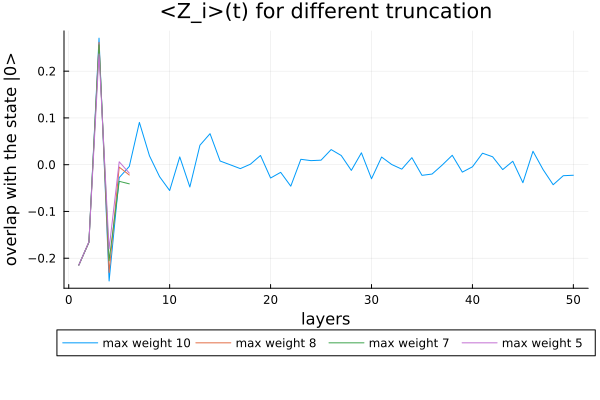

In [ ]:
p = plot(title="<Z_i>(t) for different truncation", xlabel="layers", ylabel="overlap with the state |0>")

for (i, overlap) in enumerate(reverse(overlap_max_weight))
    plot!(p, 1:length(overlap), overlap, label="max weight $(reverse(max_weight_list)[i])")
end
plot!(legend=:outerbottom, legendcolumns=length(overlap_max_weight))

display(p)

### Observation

We observe that for a maximum weight below the number of Qubits, our method no longer correctly simulates a quantum state, $\sum_\alpha |c_\alpha|^2$ deviates from 1.

This seems consistent with the type of circuit through which we propagate our observable.
Indeed, a circuit composed of random gates creates a lot of correlation between the qubits. Consequently, a max weight that is too small avoids strong correlations and thus takes us drastically away from the exact physical state, which is highly correlated.

---

### 2.2.2 Minimum absolute coefficient

In [ ]:
# the truncations
max_weight = nqubits
min_abs_coeff_idx = round.(Int, range(4, 8, 4))
min_abs_coeff_list = 10.0 .^ .-min_abs_coeff_idx

overlap_min_min_abs_coeff = Vector[]
for min_abs_coeff in min_abs_coeff_list
    println("Min abs coefficient: ",min_abs_coeff)
    pauli_sum, result = pp.propagate_layerbylayer(circuit, observable, nlayers; max_weight, min_abs_coeff)
    push!(overlap_min_min_abs_coeff, result["overlap"])
end

Min abs coefficient: 0.0001
layer : 0/50 complete
layer : 5/50 Break cause pauli norm = 0.9823382339587032 ≠ 1
Time taken by propagate_layerbylayer: 56.77999997138977 seconds
Min abs coefficient: 1.0e-5
layer : 0/50 complete
layer : 5/50 Break cause pauli norm = 0.9999711505918966 ≠ 1
Time taken by propagate_layerbylayer: 59.73099994659424 seconds
Min abs coefficient: 1.0000000000000001e-7
layer : 0/50 complete
layer : 5/50 complete
layer : 10/50 complete
layer : 15/50 complete
layer : 20/50 complete
layer : 25/50 complete
layer : 30/50 complete
layer : 35/50 complete
layer : 40/50 complete
layer : 45/50 complete
Time taken by propagate_layerbylayer: 843.2600002288818 seconds
Min abs coefficient: 1.0e-8
layer : 0/50 complete
layer : 5/50 complete
layer : 10/50 complete
layer : 15/50 complete
layer : 20/50 complete
layer : 25/50 complete
layer : 30/50 complete
layer : 35/50 complete
layer : 40/50 complete
layer : 45/50 complete
Time taken by propagate_layerbylayer: 880.1099998950958 sec

---

### Plot and Result

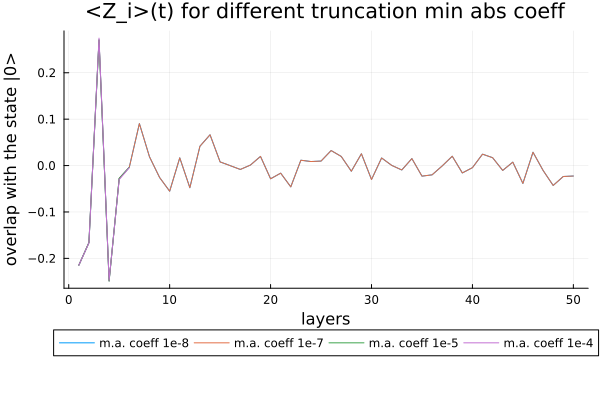

In [ ]:
p = plot(title="<Z_i>(t) for different truncation min abs coeff", xlabel="layers", ylabel="overlap with the state |0>")

for (i, overlap) in enumerate(reverse(overlap_min_min_abs_coeff))
    plot!(p, 1:length(overlap), overlap, label="m.a. coeff 1e-$(reverse(min_abs_coeff_idx)[i])")
end
plot!(legend=:outerbottom, legendcolumns=length(overlap_min_min_abs_coeff))

display(p)


### Observation

It is clear that we need a value smaller than $10^{-5}$, so we will use $10^{-7}$.

---

## 2.3 Summary

For the next simulations, we can use the layer by layer propagation with :
- a minimum absolute value of $10^{-7}$,
- a maximum weight equal to **qubit's number**.

---

# 3. Matrix Product Operator (MPO) method

In [72]:
# nombre de spins
nqubits = 8

# creation des sites
sites = ITensors.siteinds("S=1/2", nqubits)

8-element Vector{Index{Int64}}:
 (dim=2|id=311|"S=1/2,Site,n=1")
 (dim=2|id=469|"S=1/2,Site,n=2")
 (dim=2|id=250|"S=1/2,Site,n=3")
 (dim=2|id=694|"S=1/2,Site,n=4")
 (dim=2|id=414|"S=1/2,Site,n=5")
 (dim=2|id=365|"S=1/2,Site,n=6")
 (dim=2|id=118|"S=1/2,Site,n=7")
 (dim=2|id=736|"S=1/2,Site,n=8")

In [73]:
# Z_5
j = 4

ops = ["Id" for n in 1:nqubits]
ops[j] = "Z"
Z_j = MPO(sites, ops)

8-element MPO:
 ((dim=2|id=311|"S=1/2,Site,n=1")', (dim=2|id=311|"S=1/2,Site,n=1"), (dim=1|id=310|"Link,l=1"))
 ((dim=2|id=469|"S=1/2,Site,n=2")', (dim=2|id=469|"S=1/2,Site,n=2"), (dim=1|id=49|"Link,l=2"), (dim=1|id=310|"Link,l=1"))
 ((dim=2|id=250|"S=1/2,Site,n=3")', (dim=2|id=250|"S=1/2,Site,n=3"), (dim=1|id=98|"Link,l=3"), (dim=1|id=49|"Link,l=2"))
 ((dim=2|id=694|"S=1/2,Site,n=4")', (dim=2|id=694|"S=1/2,Site,n=4"), (dim=1|id=24|"Link,l=4"), (dim=1|id=98|"Link,l=3"))
 ((dim=2|id=414|"S=1/2,Site,n=5")', (dim=2|id=414|"S=1/2,Site,n=5"), (dim=1|id=63|"Link,l=5"), (dim=1|id=24|"Link,l=4"))
 ((dim=2|id=365|"S=1/2,Site,n=6")', (dim=2|id=365|"S=1/2,Site,n=6"), (dim=1|id=189|"Link,l=6"), (dim=1|id=63|"Link,l=5"))
 ((dim=2|id=118|"S=1/2,Site,n=7")', (dim=2|id=118|"S=1/2,Site,n=7"), (dim=1|id=720|"Link,l=7"), (dim=1|id=189|"Link,l=6"))
 ((dim=2|id=736|"S=1/2,Site,n=8")', (dim=2|id=736|"S=1/2,Site,n=8"), (dim=1|id=720|"Link,l=7"))

In [74]:
cutoff = 1e-5
nlayers = 50
topology = bricklayertopology(nqubits; periodic=true)

_, circuit = random_brick_circuit(nqubits, nlayers; topology)
ψ0 = MPS(sites, ["Up" for _ in 1:nqubits]) # |↑↑..↑>

8-element MPS:
 ((dim=2|id=311|"S=1/2,Site,n=1")', (dim=1|id=266|"Link,l=1"))
 ((dim=1|id=266|"Link,l=1"), (dim=2|id=469|"S=1/2,Site,n=2")', (dim=1|id=887|"Link,l=2"))
 ((dim=1|id=887|"Link,l=2"), (dim=2|id=250|"S=1/2,Site,n=3")', (dim=1|id=655|"Link,l=3"))
 ((dim=1|id=655|"Link,l=3"), (dim=2|id=694|"S=1/2,Site,n=4")', (dim=1|id=822|"Link,l=4"))
 ((dim=1|id=822|"Link,l=4"), (dim=2|id=414|"S=1/2,Site,n=5")', (dim=1|id=665|"Link,l=5"))
 ((dim=1|id=665|"Link,l=5"), (dim=2|id=365|"S=1/2,Site,n=6")', (dim=1|id=125|"Link,l=6"))
 ((dim=1|id=125|"Link,l=6"), (dim=2|id=118|"S=1/2,Site,n=7")', (dim=1|id=310|"Link,l=7"))
 ((dim=1|id=310|"Link,l=7"), (dim=2|id=736|"S=1/2,Site,n=8")')

layer : 5 /50 complete
layer : 10 /50 complete
layer : 15 /50 complete
layer : 20 /50 complete
layer : 25 /50 complete
layer : 30 /50 complete
layer : 35 /50 complete
layer : 40 /50 complete
layer : 45 /50 complete
layer : 50 /50 complete
Time taken by mpo_functions.propagate_layerbylayer: 169.35020995140076 seconds


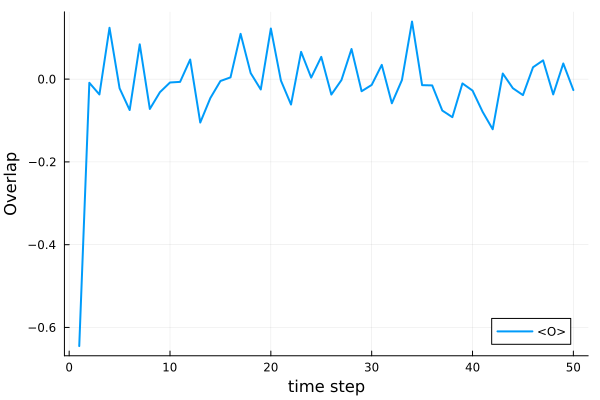

In [75]:
Ot, result = mpo.propagate_layerbylayer(circuit, Z_j; cutoff, psi0)

overlap_values = result["overlap"]

plot(1:nlayers, overlap_values,
     xlabel="time step",
     ylabel="Overlap",
     label="<O>",
     lw=2)

---

# 4. MPO vs Pauli

## 4.1 initialisation

In [311]:
nqubits = 2
nlayers = 10

topology = bricklayertopology(nqubits; periodic=true)

# creation des sites, on a besoin de l'init avant le circuit
sites = ITensors.siteinds("S=1/2", nqubits)

# define the circuit
circuit_pp, circuit_mpo = random_brick_circuit(nqubits, nlayers; topology)

# for Z_i
i=1

1

### Pauli Propagation

In [312]:
# the truncations
max_weight = nqubits
min_abs_coeff = 1e-7

# psi0
# ψ0_pp = a faire

# Z_4
Z_i_pp = PauliString(nqubits, :Z, i) # I...IZI...I

PauliString(nqubits: 2, 1.0 * ZI)

### MPO

In [313]:
# the truncations
cutoff = 1e-8

# psi0
ψ0 = MPS(sites, ["Up" for _ in 1:nqubits]) # |↑↑..↑>

# Z_4
ops = ["Id" for n in 1:nqubits]
ops[i] = "Z"
Z_i_mpo = MPO(sites, ops)

2-element MPO:
 ((dim=2|id=537|"S=1/2,Site,n=1")', (dim=2|id=537|"S=1/2,Site,n=1"), (dim=1|id=87|"Link,l=1"))
 ((dim=2|id=457|"S=1/2,Site,n=2")', (dim=2|id=457|"S=1/2,Site,n=2"), (dim=1|id=87|"Link,l=1"))

---

## 4.2 Propagation

In [321]:
include("matrix_product_operator_functions.jl")
import .mpo_functions as mpo
include("pauli_propagation_functions.jl")
import .pauli_propagation_functions as pp

In [315]:
println("Pauli Propagation method")
Z_it_pp, result_pp = pp.propagate_layerbylayer(circuit_pp, Z_i_pp, nlayers; max_weight, min_abs_coeff)
println("---")

Pauli Propagation method
layer : 1/10 complete
layer : 2/10 complete
layer : 3/10 complete
layer : 4/10 complete
layer : 5/10 complete
layer : 6/10 complete
layer : 7/10 complete
layer : 8/10 complete
layer : 9/10 complete
layer : 10/10 complete
Time taken by pp.propagate_layerbylayer: 0.0016050338745117188 seconds
---


In [319]:
println("Matrix Product Operator method")
Z_it_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, ψ0)
println("---")

Matrix Product Operator method
layer : 1 /10 complete
layer : 2 /10 complete
layer : 3 /10 complete
layer : 4 /10 complete
layer : 5 /10 complete
layer : 6 /10 complete
layer : 7 /10 complete
layer : 8 /10 complete
layer : 9 /10 complete
layer : 10 /10 complete
Time taken by mpo_functions.propagate_layerbylayer: 0.5880482196807861 seconds
---


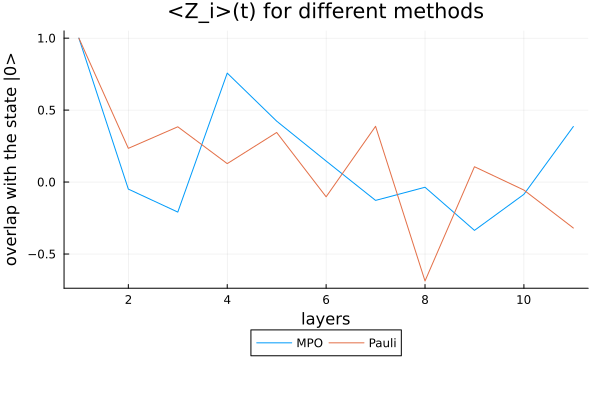

In [320]:
p = plot(title="<Z_i>(t) for different methods", xlabel="layers", ylabel="overlap with the state |0>")

plot!(p, 1:length(result_mpo["overlap"]), result_mpo["overlap"], label="MPO")
plot!(p, 1:length(result_pp["overlap"]), result_pp["overlap"], label="Pauli")
plot!(legend=:outerbottom, legendcolumns=2)

display(p)

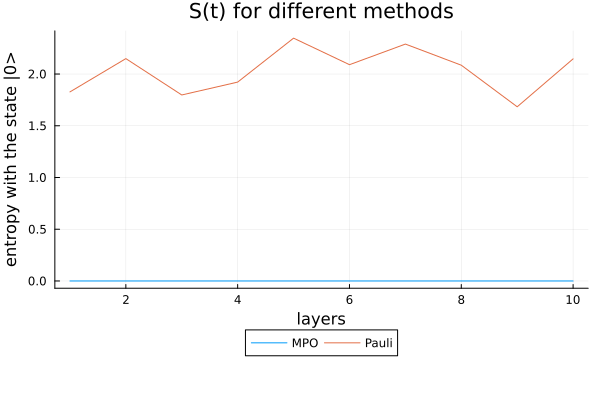

In [296]:
p = plot(title="S(t) for different methods", xlabel="layers", ylabel="entropy with the state |0>")

plot!(p, 1:length(result_mpo["S"]), result_mpo["S"], label="MPO")
plot!(p, 1:length(result_pp["S"]), result_pp["S"], label="Pauli")
plot!(legend=:outerbottom, legendcolumns=2)

display(p)

Les deux methodes donne des resultats clairement different.

Probleme dans l'implementation de la methode MPO, la pauli propagation a passé plus de test et vérification.

---

## References

- https://arxiv.org/abs/2505.21606
- https://github.com/MSRudolph/PauliPropagation.jl
- https://cheatsheet.juliadocs.org/
- https://arxiv.org/abs/math-ph/0609050
- [Julia documentation](https://docs.julialang.org/en/v1/)
- Latex Tiks documentation https://www.overleaf.com/learn/latex/LaTeX_Graphics_using_TikZ%3A_A_Tutorial_for_Beginners_(Part_3)%E2%80%94Creating_Flowcharts
